In [ ]:
%env HF_TOKEN=hf_XXX


In [2]:
from smolagents import CodeAgent, InferenceClientModel
import os

model = InferenceClientModel()

# default model
model.client

<InferenceClient(model='Qwen/Qwen2.5-Coder-32B-Instruct', timeout=120)>

In [3]:
from smolagents import CodeAgent, InferenceClientModel

model_id = "meta-llama/Llama-3.3-70B-Instruct" 

llama_model = InferenceClientModel(model_id=model_id, token=os.environ['HF_TOKEN']) # You can choose to not pass any model_id to InferenceClientModel to use a default model
# you can also specify a particular provider e.g. provider="together" or provider="sambanova"
agent = CodeAgent(tools=[], model=llama_model, add_base_tools=True)

agent.run(
    "Could you give me the 118th number in the Fibonacci sequence?",
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Could you give me the 118th number in the Fibonacci sequence?                                                   │
│                                                                                                                 │
╰─ InferenceClientModel - meta-llama/Llama-3.3-70B-Instruct ──────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  def fibonacci(n):                                                                                                
      fib_sequence = [0, 1]                                                                                        
      while len(fib_sequence) < n:                                                                                 
          fib_sequence.append(fib_sequence[-1] + fib_sequence[-2])                                                 
      return fib_sequence[-1]                                                                                      
                                                                                                                   
  result = fibonacci(119) # The sequence is 0-indexed, so we need to generate 119 numbers to get the 118th number  
  print(result)                                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
2046711111473984623691759

Out: None

[Step 1: Duration 4.49 seconds| Input tokens: 2,039 | Output tokens: 150]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer(2046711111473984623691759)                                                                          
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out - Final answer: 2046711111473984623691759

[Step 2: Duration 1.41 seconds| Input tokens: 4,381 | Output tokens: 209]

2046711111473984623691759

## Claude
<img src="../images/claudefib.png" alt="Claude Screenshot" width="400"/>

## OpenAI
<img src="../images/openaifib.png" alt="OpenAI Screenshot" width="400"/>


## DeepSeek
<img src="../images/deepseekfib.png" alt="DeepSeek Screenshot" width="400"/>

In [12]:
# Llama said 2,046,711,111,473,984,623,691,759
# OpenAI said 2,046,711,111,473,984,623,691,759
# Claude said 4,224,696,333,392,220,272,978,344,770,991,272,720,046,789
# DeepSeek gave code that yields 2,046,711,111,473,984,623,691,759 but then SAID 3,311,648,143,516,982,017,180,081

# sooo who's right? Your homework is to figure out who ;) 
#  Hint, assumptions are being made and the AI's disagree on what assumption to make.

In [7]:
agent.run("Could you get me the title of the page at url 'https://huggingface.co/blog'?")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Could you get me the title of the page at url 'https://huggingface.co/blog'?                                    │
│                                                                                                                 │
╰─ InferenceClientModel - meta-llama/Llama-3.3-70B-Instruct ──────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import re                                                                                                        
  url = "https://huggingface.co/blog"                                                                              
  page_content = visit_webpage(url)                                                                                
  title_match = re.search(r"<title>(.*?)</title>", page_content)                                                   
  if title_match:                                                                                                  
      title = title_match.group(1)                                                                                 
      print(title)                                                                                                 
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out: None

[Step 1: Duration 0.71 seconds| Input tokens: 2,093 | Output tokens: 113]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("Hugging Face – Blog")                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out - Final answer: Hugging Face – Blog

[Step 3: Duration 0.12 seconds| Input tokens: 12,204 | Output tokens: 288]

'Hugging Face – Blog'

In [4]:
from smolagents import Tool
from IPython.display import Image, display

image_generation_tool = Tool.from_space(
    "black-forest-labs/FLUX.1-schnell",
    name="image_generator",
    description="Generate an image from a prompt"
)

image_generation_tool("A sunny beach")

Loaded as API: https://black-forest-labs-flux-1-schnell.hf.space ✔


Since `api_name` was not defined, it was automatically set to the first available API: `/infer`.


'/private/var/folders/y9/9xqbqkg90tnc0cmm0dxt985m0000gn/T/gradio/de9f461ff8f2c29b883c460098bd4fa74b9811bf80617feab9bc5c746a70ea4c/image.webp'

In [6]:
agent = CodeAgent(tools=[image_generation_tool], model=llama_model, add_base_tools=True)  # base tools include duckduckgo

agent.run(
    "Look up the weather in SF today, describe it and draw an image based on it",
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Look up the weather in SF today, describe it and draw an image based on it                                      │
│                                                                                                                 │
╰─ InferenceClientModel - meta-llama/Llama-3.3-70B-Instruct ──────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  sf_weather = web_search(query="San Francisco weather today")                                                     
  print(sf_weather)                                                                                                
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Code execution failed at line 'sf_weather = web_search(query="San Francisco weather today")' due to: 
DuckDuckGoSearchException: https://html.duckduckgo.com/html 202 Ratelimit

[Step 1: Duration 3.62 seconds| Input tokens: 2,070 | Output tokens: 66]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 5 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import random                                                                                                    
  image = image_generator("A picture of the San Francisco skyline on a partly cloudy day with wind blowing at      
  35-55 mph.")                                                                                                     
  final_answer("The current weather in San Francisco is partly cloudy with a high of 58°F and a low of 45°F.       
  There is a Wind Advisory in effect from 10 PM Tuesday to 4 PM Wednesday, with gusty southerly winds of 35 to 55  
  mph and isolated gusts of 65 mph. Here is an image of the San Francisco skyline on a partly cloudy day with      
  wind blowing at 35-55 mph: " + image)                                                                            
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out - Final answer: The current weather in San Francisco is partly cloudy with a high of 58°F and a low of 45°F. 
There is a Wind Advisory in effect from 10 PM Tuesday to 4 PM Wednesday, with gusty southerly winds of 35 to 55 mph
and isolated gusts of 65 mph. Here is an image of the San Francisco skyline on a partly cloudy day with wind 
blowing at 35-55 mph: 
/private/var/folders/y9/9xqbqkg90tnc0cmm0dxt985m0000gn/T/gradio/cb8d52ab11b204c9dcd08a233e43ce35988fbbec98d9ed26fc5
f58a32072f11d/image.webp

[Step 5: Duration 11.77 seconds| Input tokens: 27,015 | Output tokens: 562]

'The current weather in San Francisco is partly cloudy with a high of 58°F and a low of 45°F. There is a Wind Advisory in effect from 10 PM Tuesday to 4 PM Wednesday, with gusty southerly winds of 35 to 55 mph and isolated gusts of 65 mph. Here is an image of the San Francisco skyline on a partly cloudy day with wind blowing at 35-55 mph: /private/var/folders/y9/9xqbqkg90tnc0cmm0dxt985m0000gn/T/gradio/cb8d52ab11b204c9dcd08a233e43ce35988fbbec98d9ed26fc5f58a32072f11d/image.webp'

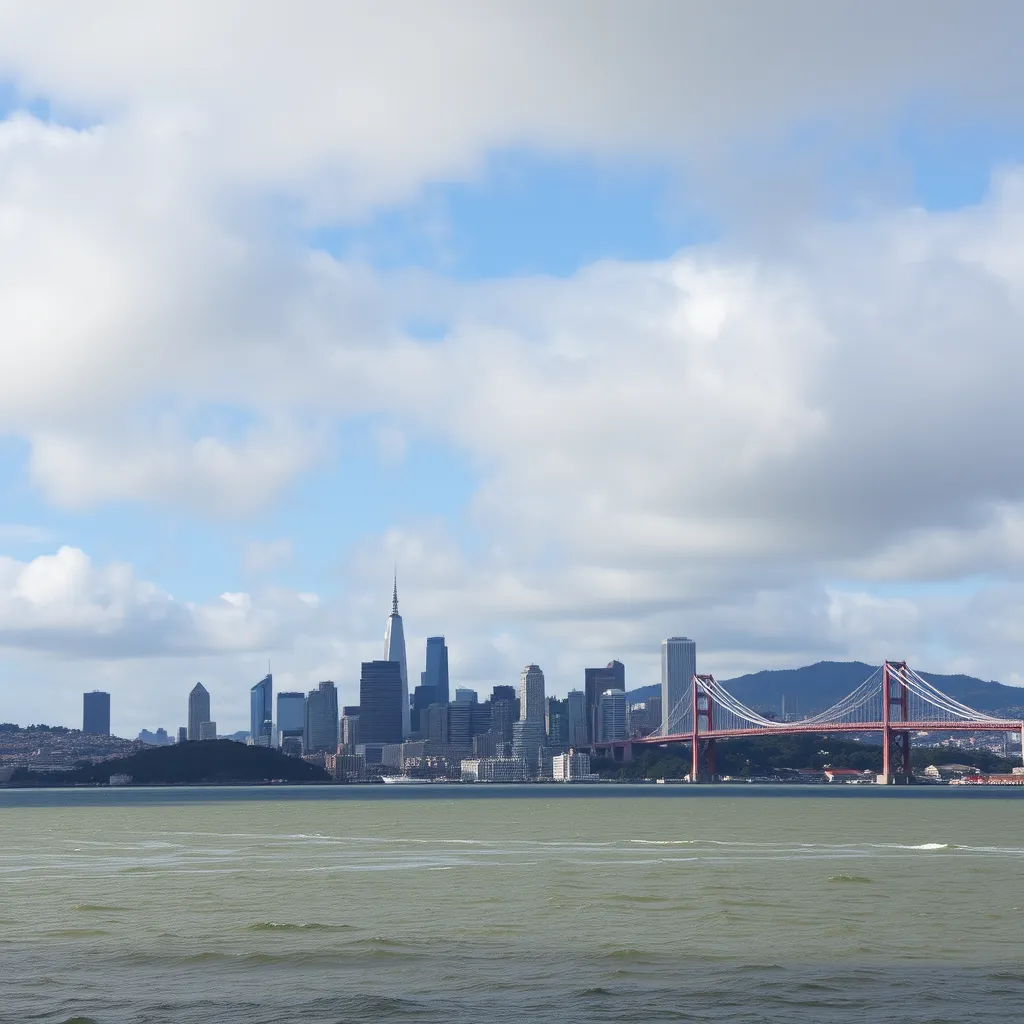

In [8]:
from IPython.display import Image, display

display(Image(filename='/private/var/folders/y9/9xqbqkg90tnc0cmm0dxt985m0000gn/T/gradio/cb8d52ab11b204c9dcd08a233e43ce35988fbbec98d9ed26fc5f58a32072f11d/image.webp'))
